# Usage Example for jam_mock_data_cube

Michele Cappellari, Oxford, 12 June 2024

In [1]:
from urllib import request
from pathlib import Path
from time import perf_counter as clock

import matplotlib.pyplot as plt
import numpy as np

from plotbin.display_pixels import display_pixels
from plotbin.plot_velfield import plot_velfield
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util

from jam_mock_data_cube import JAMCubeSimulator

## Parameters of the MGE model

In [2]:
surf, sigma, qobs = np.loadtxt('NGC300_hst_08599_02_wfpc2_f814w_pc_sci_lumdensity_cuspGaussian.txt').T

## Parameters of the JAM model

In [3]:
distance = 16.5     # Assume Virgo distance in Mpc (Mei et al. 2007)
mbh = 1e8           # Black hole mass in solar masses
beta = np.full_like(surf, 0)
inc = 60    # deg

## Parameters of the instrument

In [4]:
out_fov = .2    # arcsec FoV
out_pix = .01/3   # 10 mas scale oversampled by 3x
out_lam_range = [14e3, 18e3]    # Angstroms
out_dlam = 0.4/3                # Angstroms oversampled by 3x
redshift = 0
band_mge = 'hst/wfpc2_f814w'

## Input mock spectrum

Read SPS models file from my GitHub if not already in the `pPXF` package dir.
The SPS model files are also available on my [GitHub Page](https://github.com/micappe/ppxf_data).

In [5]:
sps_name = 'xsl'        # Use X-Shooter spectral library
ppxf_dir = Path(util.__file__).parent
basename = f"spectra_{sps_name}_9.0.npz"
filename = ppxf_dir / 'sps_models' / basename
if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    request.urlretrieve(url, filename)
a = np.load(filename)
templates, ages, metals, lam = a["templates"], a["ages"], a["metals"], a["lam"]
spectrum = templates[:, -2, -2]  # age = 12.59 Gyr [M/H] = 0

Run the simulation

In [6]:
profile = {'type': 'MGE', 'surf': surf, 'sigma': sigma, 'qobs': qobs}
out_lam = np.arange(out_lam_range[0], out_lam_range[1], out_dlam)
mock = JAMCubeSimulator(profile, inc, mbh, distance, band_mge, lam, spectrum,
                        out_fov, out_pix, out_lam, redshift, align='cyl', beta=beta)

jam.axi.proj(align='cyl', moment='z') -- elapsed time sec: 0.45
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0
inc=60.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=1.0e+08; chi2/DOF=nan
Total mass MGE (MSun): 1.071e+10

jam.axi.proj(align='cyl', moment='zz') -- elapsed time sec: 0.42
analytic_los=0 logistic=0 constant_anisotropy=1
No PSF/pixel convolution because sigmapsf=0 pixsize=0
inc=60.0; beta[0]=0.0; kappa=1.00; M/L=1.00; BH=1.0e+08; chi2/DOF=nan
Total mass MGE (MSun): 1.071e+10

--> np.median(np.diff(lam))/np.median(np.diff(out_lam)): 4.0


Show the output surface brightness

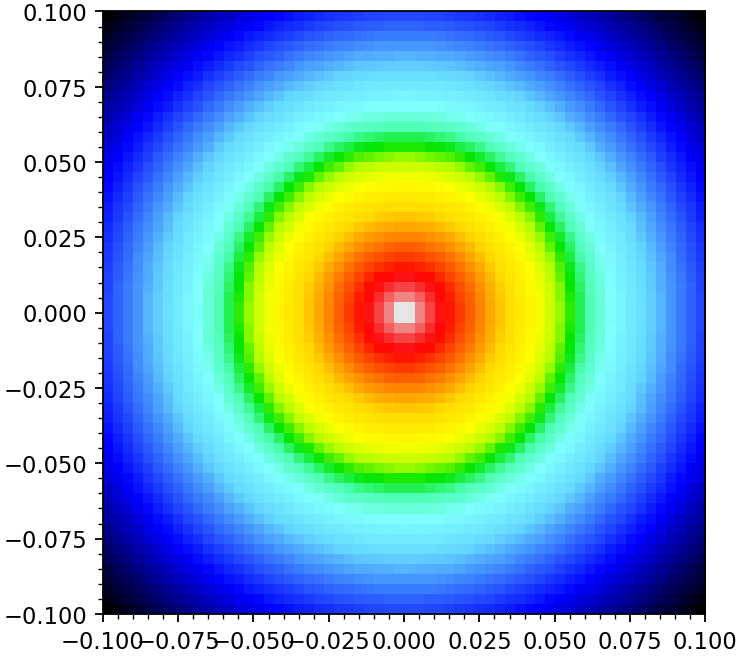

In [7]:
display_pixels(mock.x, mock.y, mock.spectra.sum(0))

## Test recovery of input kinematics with pPXF

In [8]:
velscale = 30  # km/s
galaxy_cube, ln_lam = util.log_rebin(mock.lam, mock.spectra, velscale)[:2]
template, ln_lam_temp = util.log_rebin(lam, spectrum, velscale)[:2]

template /= np.median(template)
galaxy_cube /= np.median(galaxy_cube)
goodpixels = np.arange(100, len(galaxy_cube) - 100)
velbin, sigbin = np.empty((2, galaxy_cube.shape[1]))

In [9]:
t = clock()
for j, galaxy in enumerate(galaxy_cube.T):
    pp = ppxf(template, galaxy, np.ones_like(galaxy), velscale, [0, 200], quiet=1, degree=-1,
              lam=np.exp(ln_lam), lam_temp=np.exp(ln_lam_temp), goodpixels=goodpixels)
    velbin[j], sigbin[j] = pp.sol
    if not j % 200:
        print(f"{j}/{mock.x.size}")
print(f"Elapsed time {clock() - t:.2f} s")

0/3600
200/3600
400/3600
600/3600
800/3600
1000/3600
1200/3600
1400/3600
1600/3600
1800/3600
2000/3600
2200/3600
2400/3600
2600/3600
2800/3600
3000/3600
3200/3600
3400/3600
Elapsed time 27.13 s


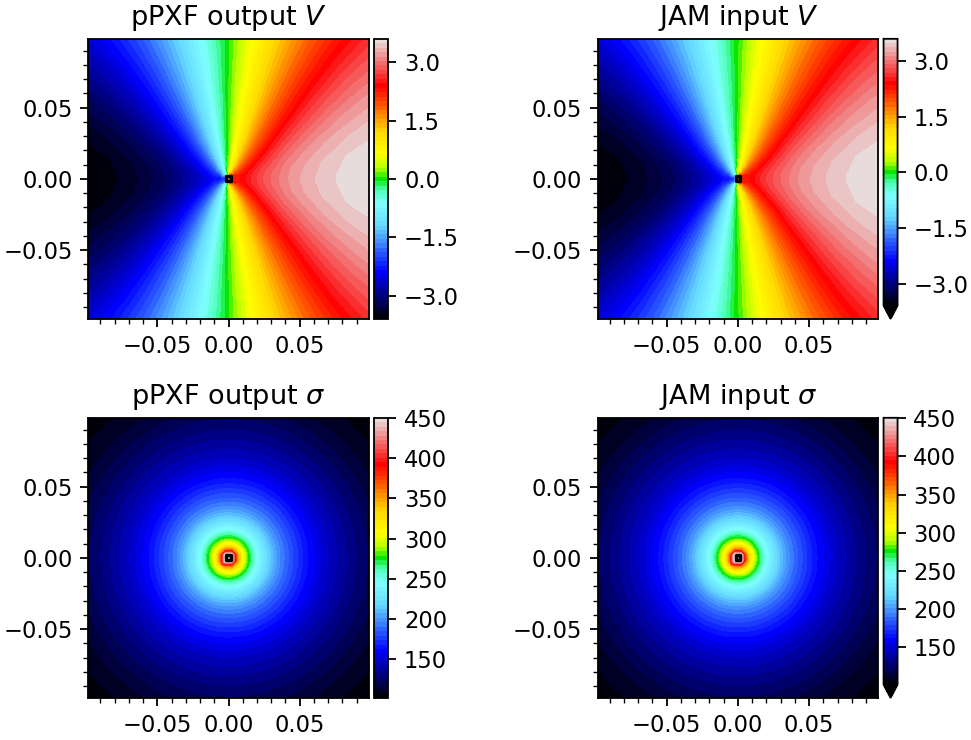

In [ ]:
plt.clf()
plt.subplot(221)
vmin, vmax = np.min(velbin), np.max(velbin)
plt.title("pPXF output $V$")
plot_velfield(mock.x, mock.y, velbin, colorbar=1, flux=mock.surf_band, 
              vmin=vmin, vmax=vmax, nodots=1)

plt.subplot(222)
plt.title("JAM input $V$")
plot_velfield(mock.x, mock.y, mock.vel, colorbar=1, flux=mock.surf_band, 
              vmin=vmin, vmax=vmax, nodots=1)

plt.subplot(223)
vmin, vmax = np.min(sigbin), np.max(sigbin)
plt.title("pPXF output $\\sigma$")
plot_velfield(mock.x, mock.y, sigbin, colorbar=1, flux=mock.surf_band, 
              vmin=vmin, vmax=vmax, nodots=1) 

plt.subplot(224)
plt.title("JAM input $\\sigma$")
plot_velfield(mock.x, mock.y, mock.sig, colorbar=1, flux=mock.surf_band, 
              vmin=vmin, vmax=vmax, nodots=1)
plt.tight_layout()

Test calibration (see Fig.1 in 
[Neumayer et al. 2020](https://ui.adsabs.harvard.edu/abs/2020A%26ARv..28....4N))
Our magnitude at `R=0.1` arcsec seems about 1 mag fainter than theirs...

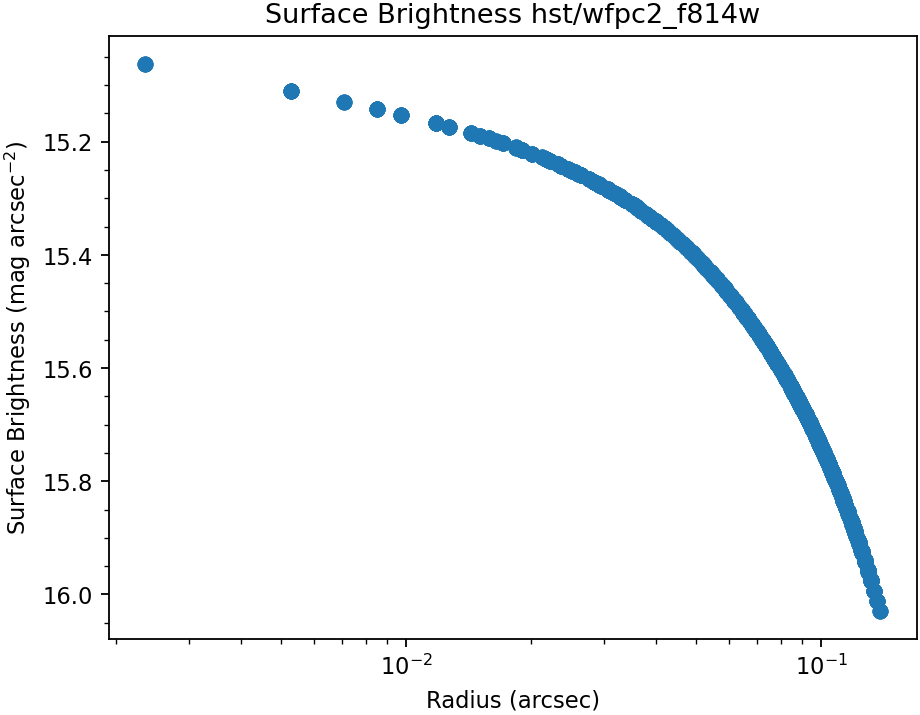

In [11]:
plt.plot(np.sqrt(mock.x**2 + mock.y**2), mock.mag_mge, 'o')
plt.xlabel("Radius (arcsec)")
plt.ylabel("Surface Brightness (mag arcsec$^{-2}$)")
plt.xscale('log') 
plt.title(f"Surface Brightness {band_mge}")
plt.gca().invert_yaxis()